# This is an implementation of a neural network in python using numpy, with pandas for data wrangling and cleaning, and pyplot for visualizing. 

# The way it works is as follows:

    - The layer class holds a weight, a bias, its input, its net input, its output, 
    and the derivative of its net input. 

    - The layer class also contains what type of activation it uses.

    - The network class holds a list of layer classes.

    - The only loss function currently supported is MSE loss.

    - To create a network, you just need to call the type of network you 
    want to use (can't do layer-by-layer activation just yet) and input a list
    containing the desired data dimensions. 

    - To train it, you call the network.train_epochs() function and input 
    training data, testing data, number of epochs, batch size, and learning rate.
    This implements stochastic gradient descent, and graphs the prediction 
    accuracy of the neural network every 10 epochs. 

    - The training data and testing data must have the following format:

        -> They must both be pandas dataframes 

        -> They must both have two columns; 'features', and 'labels'

        -> The features and label column values must all be numpy arrays
        
        -> In the case that you're using this for any type of classification, 
        the labels should be one-hot encoded. There are some swanky functions 
        included that can help you out with this type of data cleaning already.

### There's an example of all of this at the bottom of the file. 

In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
training = '/path/to/your/mnist/training.csv'
testing = '/path/to/your/mnist/testing.csv'

#getting the training data 
train = pd.read_csv(training)
test = pd.read_csv(testing)

labels = train.take([0], axis=1)
data = train.drop('label', axis=1)

#some data cleaning
def one_hot_encode(index: int, num_classes: int=10) -> np.array:
    one_hot = np.zeros(num_classes, dtype=np.float64).reshape(num_classes, 1)
    one_hot[index] = np.float64(1.0)
    return one_hot

def binarize_features(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    df_copy = df.copy()
    feature_cols = df_copy.columns.drop(label_col)
    df_copy[feature_cols] = (df_copy[feature_cols] > 0).astype(int)
    return df_copy

def clean_mnist(data: pd.DataFrame, is_train=True):
    data.fillna(value=-1, inplace=True)
    
    res = pd.DataFrame()
    

    if is_train:
        labels = data.columns[1:len(data.columns)]
    else:
        labels = data.columns
    
    res['features'] = data[labels].apply(lambda row: np.array(row.values, 
                                        dtype=int).reshape(784, 1), axis=1)
    
    if is_train:
        res['labels'] = data['label'].apply(lambda row: one_hot_encode(row))
    
    return res

In [4]:
class layer:

    def __init__(self, dims: tuple[int, int]):
        self.rows = dims[0]
        self.cols = dims[1]
        self.W = np.random.randn(self.cols, self.rows) 
        self.b = np.random.randn(self.cols, 1) 
        self.A = np.ones((self.cols, 1))
        self.Z = np.ones((self.cols, 1))
        self.Z_Prime = np.ones((self.cols, 1))
        self.X = np.ones((self.cols, 1))

    def activation(self, x: float):
        pass

    def activation_deriv(self, x: float):
        pass

    def calc_z(self, x: np.array):
        self.Z = np.dot(self.W, x) + self.b
        return self.Z

    def calc_out(self):
        vectorized_activation = np.vectorize(self.activation)
        self.A = vectorized_activation(self.Z)
        return self.A

class sigmoid_layer(layer):

    def __init__(self, dims: tuple[int, int]):
        super().__init__(dims)

    def activation(self, x: float):
        return 1/(1 + np.exp(-x))

    def activation_vectorized(self, x: np.array):
        vec_act = np.vectorize(self.activation)
        self.A = vec_act(self.Z)

    def activation_deriv(self, x: float):
        sgm_prime = self.activation(x)
        return sgm_prime * (1 - sgm_prime)

    def activation_deriv_vectorized(self):
        vectorized_activation_deriv = np.vectorize(self.activation_deriv)
        self.Z_Prime = vectorized_activation_deriv(self.Z)
        return self.Z_Prime

class network():

    def __init__(self, layers: list[int]):
        pass

    def feedforward(self, X: np.array):
        #make sure x is an nx1 vector
        #first feedforward for the first one, then loop over the rest 
        first = self.layers[0]
        
        first.calc_z(X)
        first.activation_vectorized(X)
        first.X = X
        
        for i in range(1, len(self.layers)):
            prev_layer = self.layers[i - 1]
            cur_layer = self.layers[i]
            
            x = prev_layer.A
            cur_layer.X = x
            cur_layer.calc_z(x)
            cur_layer.activation_vectorized(x)

        return self.layers[-1].A

    def error(self, x: np.array, y: np.array):
        y_hat = self.layers[-1].A
        return ((y - y_hat) ** 2) * 0.5

    def error_deriv(self, y: np.array):
        y_hat = self.layers[-1].A
        return y_hat - y

    def backprop_single(self, x: np.array, y: np.array):
        """ 
        res = list[tuple[np.array, np.array]]
        """
        res = []

        #do the work for the outer layer, then the rest
        outer_layer = self.layers[-1]

        dEdA = self.error_deriv(y) 
        dAdZ = outer_layer.activation_deriv_vectorized() 
        dZdW = outer_layer.X

        delta = np.multiply(dEdA, dAdZ) 

        dEdW = np.dot(delta, dZdW.T)
        dEdb = delta


        res.insert(0, (dEdW, dEdb))

        n = len(self.layers) - 2 
        
        while n >= 0:
            cur_layer = self.layers[n]
            layer_ahead = self.layers[n+1]
            
            delta_new = delta
            dZdA = layer_ahead.W 
            dAdZ = cur_layer.activation_deriv_vectorized() 
            dZdW = cur_layer.X 

            term = np.dot(dZdA.T, delta)
            delta_new = np.multiply(term, dAdZ)
            

            dEdW = np.dot(delta_new, dZdW.T)

                        
            
            dEdb = delta_new
            delta = delta_new

            res.insert(0, (dEdW, dEdb))
            n -= 1
        return res
    
    def sum_nested_gradients(self, data):
        length = len(data[0])
        batch_size = len(data)
        
        result = []
        for i in range(length):
            elems = [tup[i] for tup in data]
            arrays1, arrays2 = zip(*elems)
            sum1 = sum(arrays1)
            sum2 = sum(arrays2)
            result.append((sum1, sum2))

        for tup in result:
            new_tup = (tup[0]/batch_size, tup[1]/batch_size)
            tup = new_tup
        return result
        
    def get_data(self, data: pd.DataFrame) -> tuple[np.array, np.array]:
        # fetches some data, data has gone through clean_mnist
        max = len(data.index)
        row = np.random.randint(0, max)
        x = data['features'][row]
        y = data['labels'][row]
        return x, y
    
    def apply_grads(self, grads: list[tuple], lr: float=0.001):
        for idx, pair in enumerate(grads):
            W, b = pair 
            self.layers[idx].W -= (lr * W)
            self.layers[idx].b -= (lr * b)        

    def train(self, data: pd.DataFrame, batch_size: int=16, 
            learning_rate: float=0.001): 
        #Training and updating for a single epoch
        shuffled = data.sample(frac=1).reset_index(drop=True)
        errors = []
        max = len(shuffled)
        for i in range(0, max, batch_size):
            batch = shuffled[i:i+batch_size]
            derivs = []
            err = 0
            for _, row in batch.iterrows():
                x, y = row['features'], row['labels']
                self.feedforward(x)
                deriv = self.backprop_single(x, y) 
                derivs.append(deriv)
                error = self.error(x, y)
                err += np.linalg.norm(error)
            final_derivs = self.sum_nested_gradients(derivs)
            errors.append(err)
            self.apply_grads(final_derivs)
        final_error = np.sum(errors, axis=0)
        return final_error
    
 

    def test(self, eval: pd.DataFrame):
        #tests the accuracy of the neural network on some training data
        max = len(eval.index)
        correct = 0
        for row in range(max):
            x = eval['features'][row]
            y = eval['labels'][row]
            y_hat = self.feedforward(x)
            ans = np.argmax(y)
            guess = np.argmax(y_hat)
            if guess == ans:
                correct += 1
        return (correct/max) * 100

    def train_epochs(self, train: pd.DataFrame, 
        test: pd.DataFrame, epochs: int=1000, 
        batch_size: int = 16, learning_rate: float = 0.001):
        x_axis_1 = []
        x_axis_2 = []
        ers = []
        gambling = []

        for i in range(epochs):
            x_axis_1.append(i)
            res = self.train(train, batch_size, learning_rate)
            ers.append(res)
            if i % 10 == 0: # every 10 epochs, we're going to test
                guesses = self.test(test)
                x_axis_2.append(i)
                gambling.append(guesses)
                if i == 30:
                    print("Accuracy at 30 epochs: ", guesses, "%")

        plt.style.use("dark_background")
        plt.subplot(2, 1, 1)
        plt.plot(x_axis_1, ers, color='blue')
        plt.xlabel("Epoch #")
        plt.ylabel("Error")
        plt.title(("Model Performance: Batch Size = {}".format(batch_size)))

        plt.subplot(2, 1, 2)
        plt.scatter(x_axis_2, gambling, color='red')
        plt.xlabel("Epoch #")
        plt.ylabel("% Correct Guesses")
        plt.title(("Model Performance: Batch Size = {}").format(batch_size))

        plt.tight_layout(pad=2.5)
        plt.show()
        
class sigmoid_network(network):
    
    def __init__(self, layers: list[int]):
        self.layers = [sigmoid_layer((layers[i], layers[i+1])) for i in range(len(layers) - 1)]

    

    

/var/folders/1d/6xm2zhkx2yx8034vrx5zzq8h0000gn/T/ipykernel_92053/655308085.py:34: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-x))


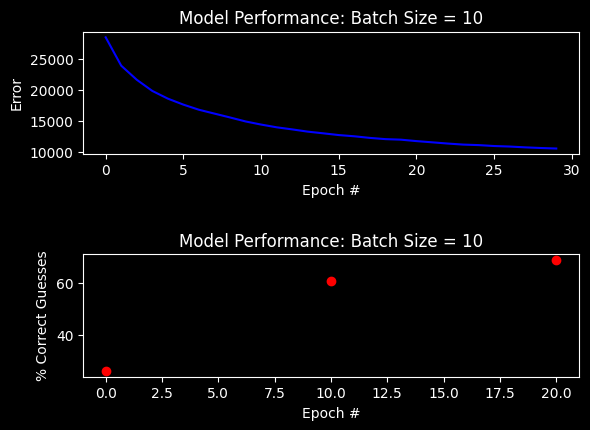

In [95]:
net = sigmoid_network([784, 30, 10])
train_data = clean_mnist(train)
test_data = clean_mnist(test)

net.train_epochs(train_data, test_data, 30, 10, 0.001)

In [96]:
net.test(test_data)

/var/folders/1d/6xm2zhkx2yx8034vrx5zzq8h0000gn/T/ipykernel_92053/655308085.py:34: RuntimeWarning: overflow encountered in exp
  return 1/(1 + np.exp(-x))


71.76